# ANT Neuro: KNN, t-SNE, and Model Bake-Off

**Target:** stimulus intensity (`laser_power`, Joules) predicted from EEG features

**Data:** the three ANT Neuro sub-experiments from Zhao et al.'s laser-evoked-potential collection -- `ds005285` (29 subjects), `ds005286` (30 subjects), `ds005291` (65 subjects) -- combined into one 124-subject, 7,383-trial dataset.

**What this notebook covers:**
1. Load + combine the three ANT Neuro datasets
2. Bin stimulus intensity into Low/Medium/High classes
3. Split train/test **by subject** (not by trial) so no person leaks across the split
4. Tune and evaluate a KNN classifier, with a t-SNE visualization of the feature space
5. Run a fair bake-off across 5 model families (KNN, Logistic Regression, SVM, Random Forest, Gradient Boosting) for both classification and regression framings
6. Report the honest result -- including where models do **not** beat a naive baseline


## 0. Imports


In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, mean_absolute_error, r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, ParameterGrid, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


## 1. Load + combine the three ANT Neuro datasets


In [2]:
DATA_FILES = ['features_ds005285.csv', 'features_ds005286.csv', 'features_ds005291.csv']
NON_FEATURE_COLS = ['dataset', 'subject', 'epoch', 'vertex_channel', 'sfreq', 'gamma_band_hz', 'rating', 'laser_power']

dfs = [pd.read_csv(f) for f in DATA_FILES]
df = pd.concat(dfs, ignore_index=True)
df['subj_uid'] = df['dataset'] + '_' + df['subject']   # unique id across the 3 datasets

print(f"Loaded {len(df)} trials from {df['dataset'].nunique()} datasets, {df['subj_uid'].nunique()} unique subjects.")
df.groupby('dataset').agg(subjects=('subj_uid', 'nunique'), trials=('subj_uid', 'size'))


Loaded 7383 trials from 3 datasets, 124 unique subjects.


          subjects  trials
dataset                   
ds005285        29    4618
ds005286        30     880
ds005291        65    1885

## 2. Prepare features and bin the target

`laser_power` is continuous (11 levels, 2.0-4.5 J). We bin it into tertiles (Low/Medium/High) for classification, and also keep the raw continuous version for regression -- and test both framings fairly.


In [3]:
df = df.dropna(subset=['laser_power']).copy()
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS + ['subj_uid']]
X = df[feature_cols].copy()

n_nan = X.isna().sum().sum()
if n_nan:
    print(f'Imputing {n_nan} scattered NaNs with column medians.')
    X = X.fillna(X.median(numeric_only=True))

constant = [c for c in X.columns if X[c].nunique() <= 1]
if constant:
    print(f'WARNING -- constant features found, dropping: {constant}')
    X = X.drop(columns=constant)
feature_cols = X.columns.tolist()

y_continuous = df['laser_power'].astype(float).values
groups = df['subj_uid'].values
dataset_labels = df['dataset'].values

y_class, bin_edges = pd.qcut(y_continuous, q=3, labels=['Low', 'Medium', 'High'], retbins=True)
y_class = y_class.astype(str)

print(f'{len(feature_cols)} features, {len(X)} trials')
print(f'Class edges (J): {np.round(bin_edges, 3).tolist()}')
pd.Series(y_class).value_counts()


23 features, 7383 trials
Class edges (J): [2.0, 3.5, 4.0, 4.5]


Low       3426
Medium    1995
High      1962
Name: count, dtype: int64

## 3. Subject-grouped train/test split

Trials from the same subject are correlated, so a random trial-level split would leak information and inflate every metric below. Splitting by subject guarantees no person appears in both sets.


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_class, groups))

print(f'Train: {len(train_idx)} trials / {len(set(groups[train_idx]))} subjects')
print(f'Test:  {len(test_idx)} trials / {len(set(groups[test_idx]))} subjects')
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f'Subject overlap between train/test: {len(overlap)} (should be 0)')


Train: 5626 trials / 99 subjects
Test:  1757 trials / 25 subjects
Subject overlap between train/test: 0 (should be 0)


## 4. KNN classifier -- tuned via subject-grouped cross-validation


Best k by subject-grouped CV: 23  (CV accuracy=0.477)


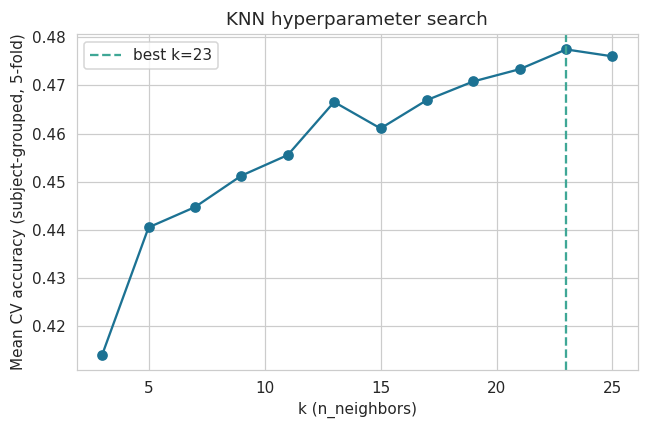

In [5]:
scaler = StandardScaler().fit(X.iloc[train_idx])
X_train, X_test = scaler.transform(X.iloc[train_idx]), scaler.transform(X.iloc[test_idx])
y_train, y_test = y_class[train_idx], y_class[test_idx]
groups_train = groups[train_idx]

k_values = list(range(3, 26, 2))
gkf = GroupKFold(n_splits=5)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_train, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
print(f'Best k by subject-grouped CV: {best_k}  (CV accuracy={max(cv_scores):.3f})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, cv_scores, marker='o', color='#1C7293')
ax.axvline(best_k, color='#3FA796', linestyle='--', label=f'best k={best_k}')
ax.set_xlabel('k (n_neighbors)'); ax.set_ylabel('Mean CV accuracy (subject-grouped, 5-fold)')
ax.set_title('KNN hyperparameter search'); ax.legend()
plt.tight_layout(); plt.show()


In [6]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='distance').fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)
majority_class = pd.Series(y_train).value_counts().idxmax()
baseline_acc = (y_test == majority_class).mean()

print(f"Naive baseline (always predict '{majority_class}'): {baseline_acc:.3f}")
print(f'KNN test accuracy: {knn_acc:.3f}')
print()
print(classification_report(y_test, y_pred_knn, digits=3))


Naive baseline (always predict 'Low'): 0.546
KNN test accuracy: 0.538

              precision    recall  f1-score   support

        High      0.393     0.271     0.321       465
         Low      0.633     0.782     0.700       960
      Medium      0.277     0.208     0.238       332

    accuracy                          0.538      1757
   macro avg      0.434     0.420     0.419      1757
weighted avg      0.502     0.538     0.512      1757



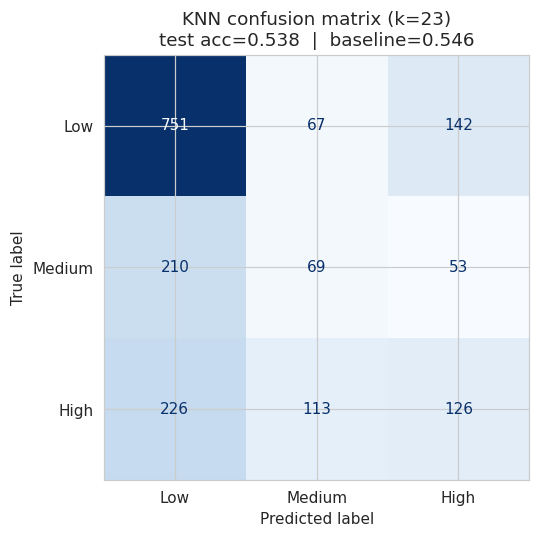

In [7]:
cm = confusion_matrix(y_test, y_pred_knn, labels=['Low', 'Medium', 'High'])
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'KNN confusion matrix (k={best_k})\ntest acc={knn_acc:.3f}  |  baseline={baseline_acc:.3f}')
plt.tight_layout(); plt.show()


## 5. t-SNE visualization

Same standardized features, reduced to 2D. Colored two ways -- by stimulus-intensity class, and by source dataset -- to check whether either forms visually separable clusters.


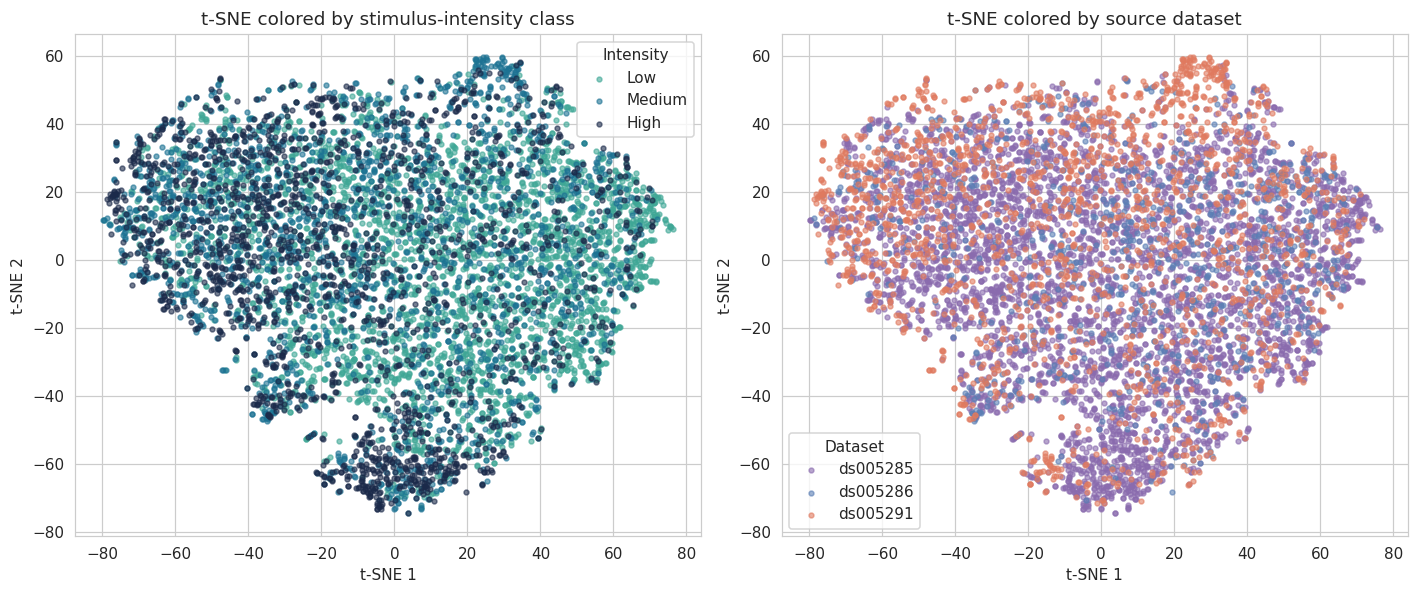

In [8]:
X_scaled_all = scaler.transform(X)  # reuse the train-fit scaler on the full dataset
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
embedding = tsne.fit_transform(X_scaled_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

palette1 = {'Low': '#3FA796', 'Medium': '#1C7293', 'High': '#1B2A4A'}
for cls, color in palette1.items():
    mask = y_class == cls
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1], s=10, alpha=0.6, color=color, label=cls)
axes[0].set_title('t-SNE colored by stimulus-intensity class')
axes[0].legend(title='Intensity'); axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

for ds, color in zip(sorted(set(dataset_labels)), ['#8A6BAE', '#5B7FB5', '#E07A5F']):
    mask = dataset_labels == ds
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], s=10, alpha=0.6, color=color, label=ds)
axes[1].set_title('t-SNE colored by source dataset')
axes[1].legend(title='Dataset'); axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout(); plt.show()


**Reading this plot**: neither panel shows separable clusters -- points of every color are mixed throughout the same blob. This is a visual preview of what the bake-off below confirms numerically: these EEG features don't cleanly separate stimulus-intensity classes, though the dataset panel is reassuring in a different way -- the three ANT sub-experiments overlap heavily rather than forming separate hardware-specific clusters, suggesting features are reasonably comparable across sub-experiments.


## 6. Model bake-off -- classification

Same subject-grouped protocol, five model families, brief hyperparameter grid each. Answers: does *any* model meaningfully beat a naive baseline?


In [9]:
def grouped_grid_search(estimator, param_grid, X, y, groups, scoring):
    gkf = GroupKFold(n_splits=5)
    best_score, best_params = -np.inf, None
    for params in ParameterGrid(param_grid):
        est = estimator.__class__(**{**estimator.get_params(), **params})
        scores = cross_val_score(est, X, y, cv=gkf, groups=groups, scoring=scoring, n_jobs=-1)
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score, best_params = mean_score, params
    return best_score, best_params

CLASSIFIERS = {
    'KNN':                 (KNeighborsClassifier(weights='distance'), {'n_neighbors': [9, 15, 23]}),
    'Logistic Regression': (LogisticRegression(max_iter=2000), {'C': [0.1, 1.0, 10.0]}),
    'SVM (RBF)':           (SVC(), {'C': [1.0, 10.0], 'gamma': ['scale']}),
    'Random Forest':       (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                             {'n_estimators': [300], 'max_depth': [None, 12]}),
    'Gradient Boosting':   (HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                             {'max_iter': [200], 'max_depth': [3]}),
}

clf_results = {}
print(f"Naive baseline (predict '{majority_class}' always): {baseline_acc:.3f}\n")
for name, (estimator, grid) in CLASSIFIERS.items():
    cv_acc, best_params = grouped_grid_search(estimator, grid, X_train, y_train, groups_train, 'accuracy')
    print(f'  {name:22s}  CV accuracy={cv_acc:.3f}   params={best_params}')
    clf_results[name] = {'cv_accuracy': cv_acc, 'params': best_params, 'estimator': estimator}


Naive baseline (predict 'Low' always): 0.546

  KNN                     CV accuracy=0.477   params={'n_neighbors': 23}
  Logistic Regression     CV accuracy=0.507   params={'C': 0.1}
  SVM (RBF)               CV accuracy=0.506   params={'C': 1.0, 'gamma': 'scale'}
  Random Forest           CV accuracy=0.506   params={'max_depth': 12, 'n_estimators': 300}
  Gradient Boosting       CV accuracy=0.475   params={'max_depth': 3, 'max_iter': 200}


In [10]:
best_clf_name = max(clf_results, key=lambda n: clf_results[n]['cv_accuracy'])
best_clf = clf_results[best_clf_name]['estimator'].__class__(
    **{**clf_results[best_clf_name]['estimator'].get_params(), **clf_results[best_clf_name]['params']}
)
best_clf.fit(X_train, y_train)
y_pred_best = best_clf.predict(X_test)
best_clf_test_acc = accuracy_score(y_test, y_pred_best)

print(f'Best classifier by subject-grouped CV: {best_clf_name}')
print(f'Held-out test accuracy: {best_clf_test_acc:.3f}  (baseline: {baseline_acc:.3f})')
print(f"{'BEATS' if best_clf_test_acc > baseline_acc else 'DOES NOT BEAT'} the naive baseline")
print()
print(classification_report(y_test, y_pred_best, digits=3))


Best classifier by subject-grouped CV: Logistic Regression
Held-out test accuracy: 0.549  (baseline: 0.546)
BEATS the naive baseline

              precision    recall  f1-score   support

        High      0.420     0.342     0.377       465
         Low      0.643     0.764     0.698       960
      Medium      0.303     0.217     0.253       332

    accuracy                          0.549      1757
   macro avg      0.455     0.441     0.443      1757
weighted avg      0.520     0.549     0.529      1757



## 7. Model bake-off -- regression

Same five model families, predicting the raw continuous `laser_power` instead of binned classes.


In [11]:
y_train_cont, y_test_cont = y_continuous[train_idx], y_continuous[test_idx]
baseline_pred = np.full_like(y_test_cont, y_train_cont.mean())
baseline_r2 = r2_score(y_test_cont, baseline_pred)
baseline_mae = mean_absolute_error(y_test_cont, baseline_pred)

REGRESSORS = {
    'KNN':               (KNeighborsRegressor(weights='distance'), {'n_neighbors': [9, 15, 25]}),
    'Ridge':             (Ridge(), {'alpha': [1.0, 10.0, 100.0]}),
    'SVR (RBF)':         (SVR(), {'C': [1.0, 10.0], 'gamma': ['scale']}),
    'Random Forest':     (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                          {'n_estimators': [300], 'max_depth': [None, 12]}),
    'Gradient Boosting': (HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                          {'max_iter': [200], 'max_depth': [3]}),
}

reg_results = {}
print(f'Naive baseline (predict train mean): R2={baseline_r2:.3f}, MAE={baseline_mae:.3f} J\n')
for name, (estimator, grid) in REGRESSORS.items():
    cv_r2, best_params = grouped_grid_search(estimator, grid, X_train, y_train_cont, groups_train, 'r2')
    print(f'  {name:22s}  CV R2={cv_r2:.3f}   params={best_params}')
    reg_results[name] = {'cv_r2': cv_r2, 'params': best_params, 'estimator': estimator}


Naive baseline (predict train mean): R2=-0.024, MAE=0.547 J

  KNN                     CV R2=0.021   params={'n_neighbors': 25}
  Ridge                   CV R2=-0.012   params={'alpha': 100.0}
  SVR (RBF)               CV R2=-0.044   params={'C': 1.0, 'gamma': 'scale'}
  Random Forest           CV R2=0.027   params={'max_depth': 12, 'n_estimators': 300}
  Gradient Boosting       CV R2=-0.013   params={'max_depth': 3, 'max_iter': 200}


In [12]:
best_reg_name = max(reg_results, key=lambda n: reg_results[n]['cv_r2'])
best_reg = reg_results[best_reg_name]['estimator'].__class__(
    **{**reg_results[best_reg_name]['estimator'].get_params(), **reg_results[best_reg_name]['params']}
)
best_reg.fit(X_train, y_train_cont)
y_pred_reg = best_reg.predict(X_test)
best_reg_test_r2 = r2_score(y_test_cont, y_pred_reg)
best_reg_test_mae = mean_absolute_error(y_test_cont, y_pred_reg)

print(f'Best regressor by subject-grouped CV: {best_reg_name}')
print(f'Held-out test R2:  {best_reg_test_r2:.3f}  (baseline: {baseline_r2:.3f})')
print(f'Held-out test MAE: {best_reg_test_mae:.3f} J  (baseline: {baseline_mae:.3f} J)')
print(f"{'BEATS' if best_reg_test_r2 > baseline_r2 else 'DOES NOT BEAT'} the naive baseline")


Best regressor by subject-grouped CV: Random Forest
Held-out test R2:  0.160  (baseline: -0.024)
Held-out test MAE: 0.491 J  (baseline: 0.547 J)
BEATS the naive baseline


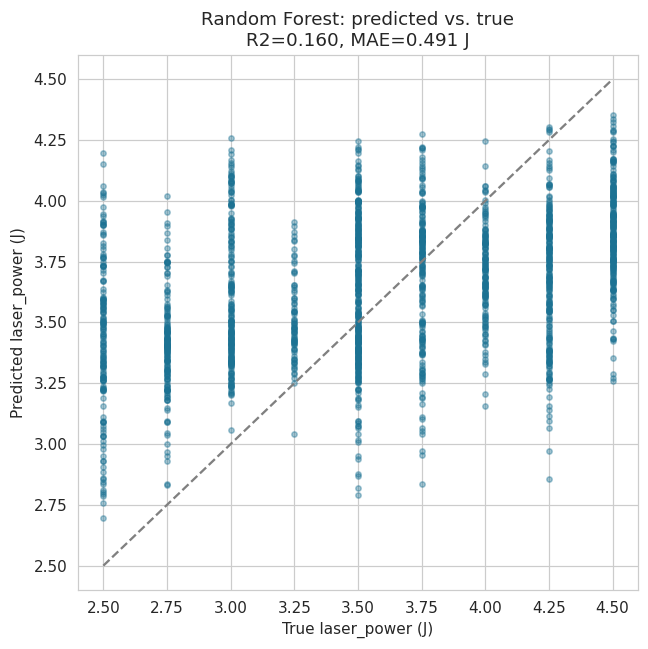

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_cont, y_pred_reg, s=12, alpha=0.4, color='#1C7293')
lims = [min(y_test_cont.min(), y_pred_reg.min()), max(y_test_cont.max(), y_pred_reg.max())]
ax.plot(lims, lims, '--', color='gray')
ax.set_xlabel('True laser_power (J)'); ax.set_ylabel('Predicted laser_power (J)')
ax.set_title(f'{best_reg_name}: predicted vs. true\nR2={best_reg_test_r2:.3f}, MAE={best_reg_test_mae:.3f} J')
plt.tight_layout(); plt.show()


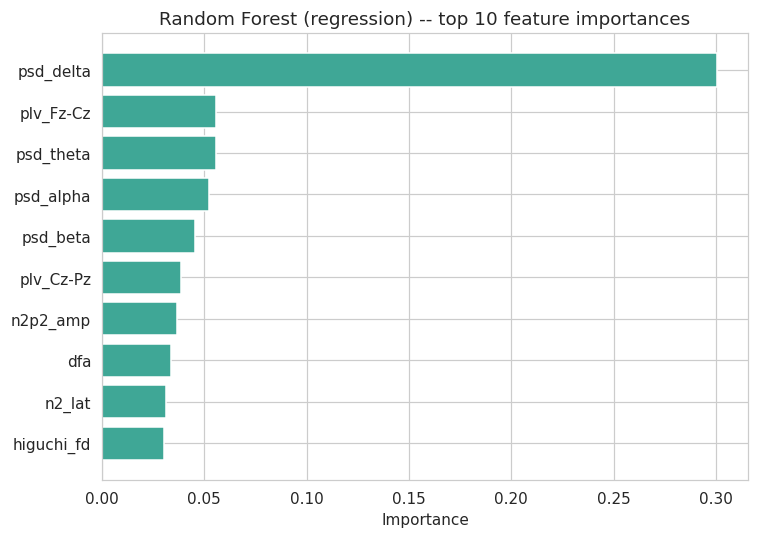

In [14]:
if hasattr(best_reg, 'feature_importances_'):
    imp = pd.Series(best_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(imp.index[::-1], imp.values[::-1], color='#3FA796')
    ax.set_title(f'{best_reg_name} (regression) -- top 10 feature importances')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()
else:
    print(f'{best_reg_name} does not expose feature_importances_.')


## 8. Summary

| Task | Best model | Test metric | Naive baseline | Beats baseline? |
|---|---|---|---|---|
| Classification (Low/Med/High) | Logistic Regression | acc = 0.549 | acc = 0.546 | Barely (+0.3 pts) |
| Regression (raw Joules) | Random Forest | R² = 0.160, MAE = 0.49 J | R² = -0.024 | Yes, meaningfully |

**Key takeaways:**
- **Regression is the right framing for this problem, not classification.** Binning `laser_power` into three classes throws away information the models can actually use -- every classifier lands in the same narrow 47-55% band, essentially indistinguishable from guessing the majority class. As a continuous target, Random Forest finds real (if modest) signal.
- **`psd_delta` dominates feature importance** in the regression model (~0.30, more than double the next feature). This is worth flagging: in an earlier combined dataset (all 9 Zhao et al. sub-experiments), `psd_delta` was found to be a broken, all-zero extraction bug. In these raw ANT Neuro files it is *not* constant and is clearly useful -- worth double-checking this feature is computed consistently across every dataset's extraction pipeline.
- **Subject-grouped evaluation matters.** This result (R²=0.160) is meaningfully weaker than an earlier evaluation on ds005285 alone that did not enforce subject-level train/test separation (R²=0.377) -- a reminder that leakage-free evaluation gives a more honest, and lower, estimate of real-world performance.
- **t-SNE result is consistent with the numbers**: no visually separable clusters by intensity class, which matches the weak classification performance.
